In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torchvision.datasets import Food101
from torch.utils.data import DataLoader, Subset
import torch.nn.functional as F
import os

## binary classification for appetizer and main course

In [2]:

# Define transform
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# Download dataset
root_dir = "/content/data"
train_set = Food101(root=root_dir, split="train", transform=transform, download=True)
test_set = Food101(root=root_dir, split="test", transform=transform, download=True)


100%|██████████| 5.00G/5.00G [03:58<00:00, 21.0MB/s]


In [3]:
# Print all class labels
print(f"Total classes: {len(train_set.classes)}")
for i, class_name in enumerate(train_set.classes):
    print(f"{i+1:>3}. {class_name}")

Total classes: 101
  1. apple_pie
  2. baby_back_ribs
  3. baklava
  4. beef_carpaccio
  5. beef_tartare
  6. beet_salad
  7. beignets
  8. bibimbap
  9. bread_pudding
 10. breakfast_burrito
 11. bruschetta
 12. caesar_salad
 13. cannoli
 14. caprese_salad
 15. carrot_cake
 16. ceviche
 17. cheese_plate
 18. cheesecake
 19. chicken_curry
 20. chicken_quesadilla
 21. chicken_wings
 22. chocolate_cake
 23. chocolate_mousse
 24. churros
 25. clam_chowder
 26. club_sandwich
 27. crab_cakes
 28. creme_brulee
 29. croque_madame
 30. cup_cakes
 31. deviled_eggs
 32. donuts
 33. dumplings
 34. edamame
 35. eggs_benedict
 36. escargots
 37. falafel
 38. filet_mignon
 39. fish_and_chips
 40. foie_gras
 41. french_fries
 42. french_onion_soup
 43. french_toast
 44. fried_calamari
 45. fried_rice
 46. frozen_yogurt
 47. garlic_bread
 48. gnocchi
 49. greek_salad
 50. grilled_cheese_sandwich
 51. grilled_salmon
 52. guacamole
 53. gyoza
 54. hamburger
 55. hot_and_sour_soup
 56. hot_dog
 57. huevos

In [4]:
# Mapping of Food101 class names to binary labels
appetizer_classes = [
    "beet_salad",
    "bruschetta",
    "caesar_salad",
    "caprese_salad",
    "cheese_plate",
    "clam_chowder",
    "crab_cakes",
    "deviled_eggs",
    "dumplings",
    "edamame",
    "escargots",
    "falafel",
    "fried_calamari",
    "garlic_bread",
    "gnocchi",
    "greek_salad",
    "guacamole",
    "gyoza",
    "hummus",
    "miso_soup",
    "mussels",
    "nachos",
    "onion_rings",
    "oysters",
    "samosa",
    "spring_rolls",
    "takoyaki"
]

main_course_classes = [
    "baby_back_ribs",
    "beef_carpaccio",
    "beef_tartare",
    "bibimbap",
    "breakfast_burrito",
    "chicken_curry",
    "chicken_quesadilla",
    "chicken_wings",
    "club_sandwich",
    "croque_madame",
    "eggs_benedict",
    "filet_mignon",
    "fish_and_chips",
    "foie_gras",
    "french_onion_soup",
    "fried_rice",
    "grilled_cheese_sandwich",
    "grilled_salmon",
    "hamburger",
    "hot_and_sour_soup",
    "hot_dog",
    "huevos_rancheros",
    "lasagna",
    "lobster_bisque",
    "lobster_roll_sandwich",
    "macaroni_and_cheese",
    "omelette",
    "pad_thai",
    "paella",
    "pancakes",
    "peking_duck",
    "pho",
    "pizza",
    "pork_chop",
    "poutine",
    "prime_rib",
    "pulled_pork_sandwich",
    "ramen",
    "ravioli",
    "risotto",
    "shrimp_and_grits",
    "spaghetti_bolognese",
    "spaghetti_carbonara",
    "steak",
    "sushi",
    "tacos",
    "tuna_tartare"
]

dessert_classes = [
    "apple_pie",
    "baklava",
    "beignets",
    "bread_pudding",
    "carrot_cake",
    "cannoli",
    "cheesecake",
    "chocolate_cake",
    "chocolate_mousse",
    "churros",
    "creme_brulee",
    "cup_cakes",
    "donuts",
    "french_toast",
    "frozen_yogurt",
    "ice_cream",
    "macarons",
    "panna_cotta",
    "red_velvet_cake",
    "strawberry_shortcake",
    "tiramisu",
    "waffles"
]




In [5]:
# Build label mapping from class name to 0 (appetizer) or 1 (main course)
# Build label mapping from class name to 0 (appetizer), 1 (main course), 2 (dessert)
label_map = {}
for idx, class_name in enumerate(train_set.classes):
    if class_name in appetizer_classes:
        label_map[idx] = 0
    elif class_name in main_course_classes:
        label_map[idx] = 1
    elif class_name in dessert_classes:
        label_map[idx] = 2


# Filter dataset to only keep images that belong to one of the three classes
def filter_indices(dataset):
    return [i for i, (_, label) in enumerate(dataset) if label in label_map]

train_indices = filter_indices(train_set)
test_indices = filter_indices(test_set)

In [6]:
train_subset = Subset(train_set, train_indices)
test_subset = Subset(test_set, test_indices)

class LabelWrapper(torch.utils.data.Dataset):
    def __init__(self, subset, label_map):
        self.subset = subset
        self.label_map = label_map

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, original_label = self.subset[idx]
        label = self.label_map[original_label]
        return image, label

train_data = LabelWrapper(train_subset, label_map)
test_data = LabelWrapper(test_subset, label_map)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64)


In [7]:


# Simple CNN for binary classification
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 16 * 16, 256)  # updated from 128 * 4 * 4
        self.fc2 = nn.Linear(256, 3)  # 3-class classification
  # Binary classification

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 128 -> 64
        x = self.pool(F.relu(self.conv2(x)))  # 64 -> 32
        x = self.pool(F.relu(self.conv3(x)))  # 32 -> 16
        x = x.view(-1, 128 * 16 * 16)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


# Training setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train for 1 epoch
model.train()
for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

print("Finished training")

Finished training


In [8]:
# Save model
model_path = "/content/binary_model_new.pth"
torch.save(model.state_dict(), model_path)
print("Model saved to:", model_path)


Model saved to: /content/binary_model_new.pth


In [19]:
from google.colab import drive
drive.mount('/content/drive')

# Copy the saved model to your Drive
!cp /content/binary_model_new.pth /content/drive/MyDrive/
print("Model copied to Google Drive in 'MyDrive'")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model copied to Google Drive in 'MyDrive'


In [9]:
# Evaluate
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Validation Accuracy: {100 * correct / total:.2f}%")

Validation Accuracy: 56.09%


In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np
import torch

# Helper function to calculate sensitivity (recall) per class
def compute_sensitivity(cm):
    TP = np.diag(cm)
    FN = np.sum(cm, axis=1) - TP
    sensitivity = TP / (TP + FN)
    return sensitivity

# Memory-safe evaluation on full dataset
def evaluate_full(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    cm = confusion_matrix(all_labels, all_preds)
    sensitivity = compute_sensitivity(cm)
    accuracy = np.trace(cm) / np.sum(cm)
    return cm, sensitivity, accuracy

# Run on full train and test sets
train_cm, train_sensitivity, train_accuracy = evaluate_full(model, train_loader, device)
val_cm, val_sensitivity, val_accuracy = evaluate_full(model, test_loader, device)

# Print results
print("\nTraining Confusion Matrix:\n", train_cm)
print("Training Sensitivity:", train_sensitivity)
print(f"Training Accuracy: {train_accuracy:.2%}")

print("\nValidation Confusion Matrix:\n", val_cm)
print("Validation Sensitivity:", val_sensitivity)
print(f"Validation Accuracy: {val_accuracy:.2%}")




Training Confusion Matrix:
 [[ 2541 17709]
 [  897 33603]]
Training Sensitivity: [0.12548148 0.974     ]
Training Accuracy: 66.02%

Validation Confusion Matrix:
 [[  866  5884]
 [  298 11202]]
Validation Sensitivity: [0.1282963  0.97408696]
Validation Accuracy: 66.13%


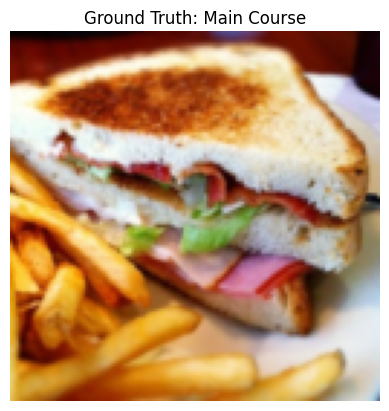

Model Prediction: Main Course


In [ ]:
import matplotlib.pyplot as plt

# Get one sample from the test set
image, label = test_data[5000]  # You can change the index (e.g., 0 → 10)

# Display the image
plt.imshow(image.permute(1, 2, 0) * 0.5 + 0.5)  # Un-normalize and show
plt.title("Ground Truth: " + ("Appetizer" if label == 0 else "Main Course"))
plt.axis("off")
plt.show()

# Predict
model.eval()
with torch.no_grad():
    image_tensor = image.unsqueeze(0).to(device)  # Add batch dimension
    output = model(image_tensor)
    _, predicted_label = torch.max(output, 1)

print("Model Prediction:", "Appetizer" if predicted_label.item() == 0 else "Main Course")


## appetizer classification

In [10]:
appetizer_classes = [
    "beet_salad",
    "bruschetta",
    "caesar_salad",
    "caprese_salad",
    "cheese_plate",
    "clam_chowder",
    "crab_cakes",
    "deviled_eggs",
    "dumplings",
    "edamame",
    "escargots",
    "falafel",
    "fried_calamari",
    "garlic_bread",
    "gnocchi",
    "greek_salad",
    "guacamole",
    "gyoza",
    "hummus",
    "miso_soup",
    "mussels",
    "nachos",
    "onion_rings",
    "oysters",
    "samosa",
    "spring_rolls",
    "takoyaki"
]

appetizer_indices = [train_set.class_to_idx[c] for c in appetizer_classes]
class_to_new_label = {idx: new_idx for new_idx, idx in enumerate(appetizer_indices)}


def filter_dataset(dataset):
    return [i for i, (_, label) in enumerate(dataset) if label in appetizer_indices]

train_subset = Subset(train_set, filter_dataset(train_set))
test_subset = Subset(test_set, filter_dataset(test_set))



In [11]:
class AppetizerDataset(torch.utils.data.Dataset):
    def __init__(self, subset, label_map):
        self.subset = subset
        self.label_map = label_map

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        return image, self.label_map[label]

train_data = AppetizerDataset(train_subset, class_to_new_label)
test_data = AppetizerDataset(test_subset, class_to_new_label)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32)

In [12]:
class AppetizerCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 128→64
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 64→32
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2)  # 32→16
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256), nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x


In [13]:
# Training setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AppetizerCNN(num_classes=len(appetizer_classes)).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# 8. Training
num_epochs = 3
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {running_loss:.4f}")



Epoch [1/3] - Loss: 1799.1549
Epoch [2/3] - Loss: 1572.0419
Epoch [3/3] - Loss: 1414.7921


In [14]:
from sklearn.metrics import confusion_matrix
import numpy as np
import torch

from sklearn.metrics import confusion_matrix
def evaluate(loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            output = model(images)
            _, predicted = torch.max(output, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    TP = np.diag(cm)
    FN = np.sum(cm, axis=1) - TP
    sensitivity = TP / (TP + FN)
    accuracy = np.trace(cm) / np.sum(cm)
    return cm, sensitivity, accuracy

# 10. Run Evaluation
train_cm, train_sens, train_acc = evaluate(train_loader)
test_cm, test_sens, test_acc = evaluate(test_loader)



In [15]:
display(train_sens, train_acc)
display(test_sens, test_acc)

array([0.39466667, 0.336     , 0.6       , 0.38933333, 0.276     ,
       0.51066667, 0.19466667, 0.25466667, 0.596     , 0.82533333,
       0.15333333, 0.05066667, 0.10533333, 0.33333333, 0.35333333,
       0.69866667, 0.44666667, 0.23066667, 0.06133333, 0.75466667,
       0.6       , 0.672     , 0.70666667, 0.628     , 0.332     ,
       0.22      , 0.26533333])

np.float64(0.40701234567901234)

array([0.268, 0.32 , 0.532, 0.24 , 0.144, 0.484, 0.12 , 0.112, 0.576,
       0.772, 0.104, 0.016, 0.052, 0.244, 0.264, 0.576, 0.368, 0.128,
       0.064, 0.58 , 0.6  , 0.564, 0.616, 0.612, 0.244, 0.092, 0.192])

np.float64(0.329037037037037)

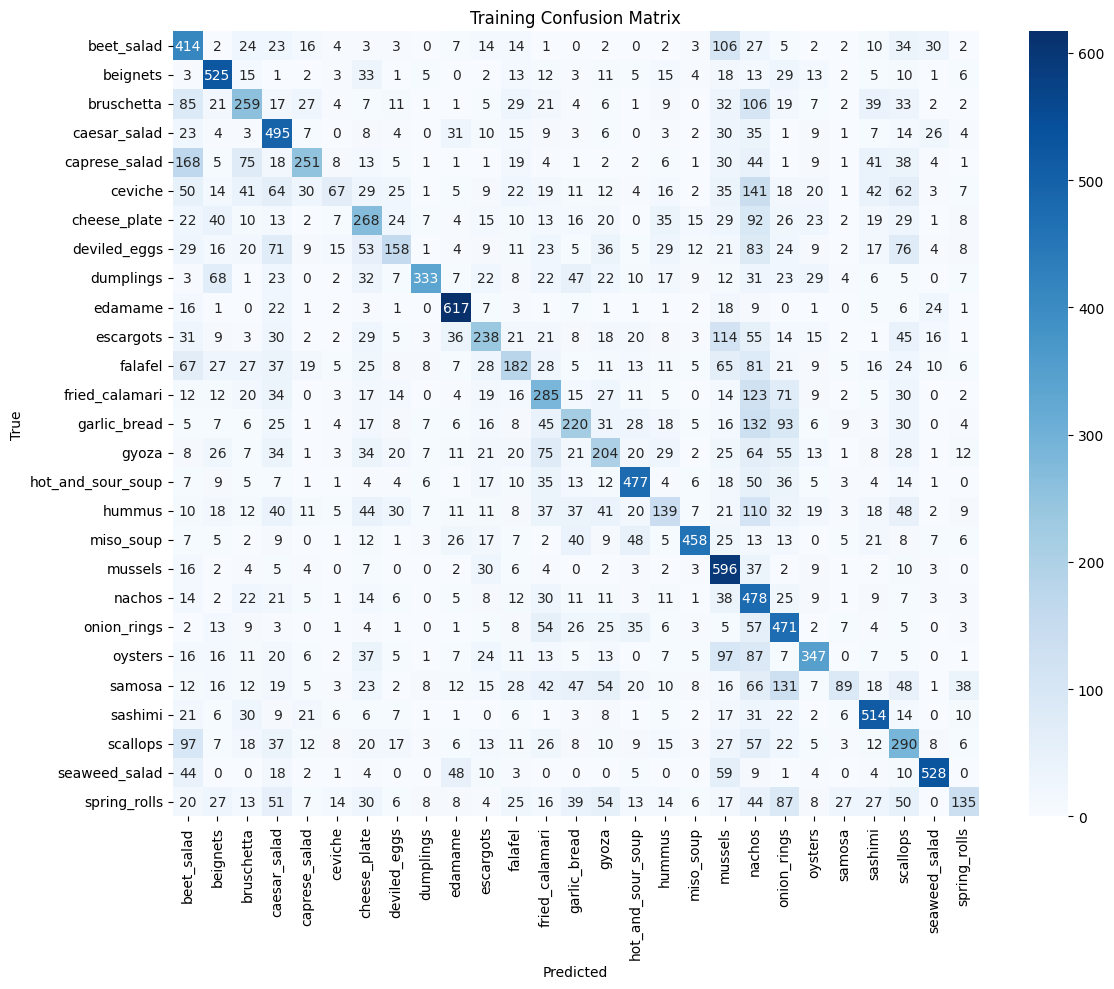

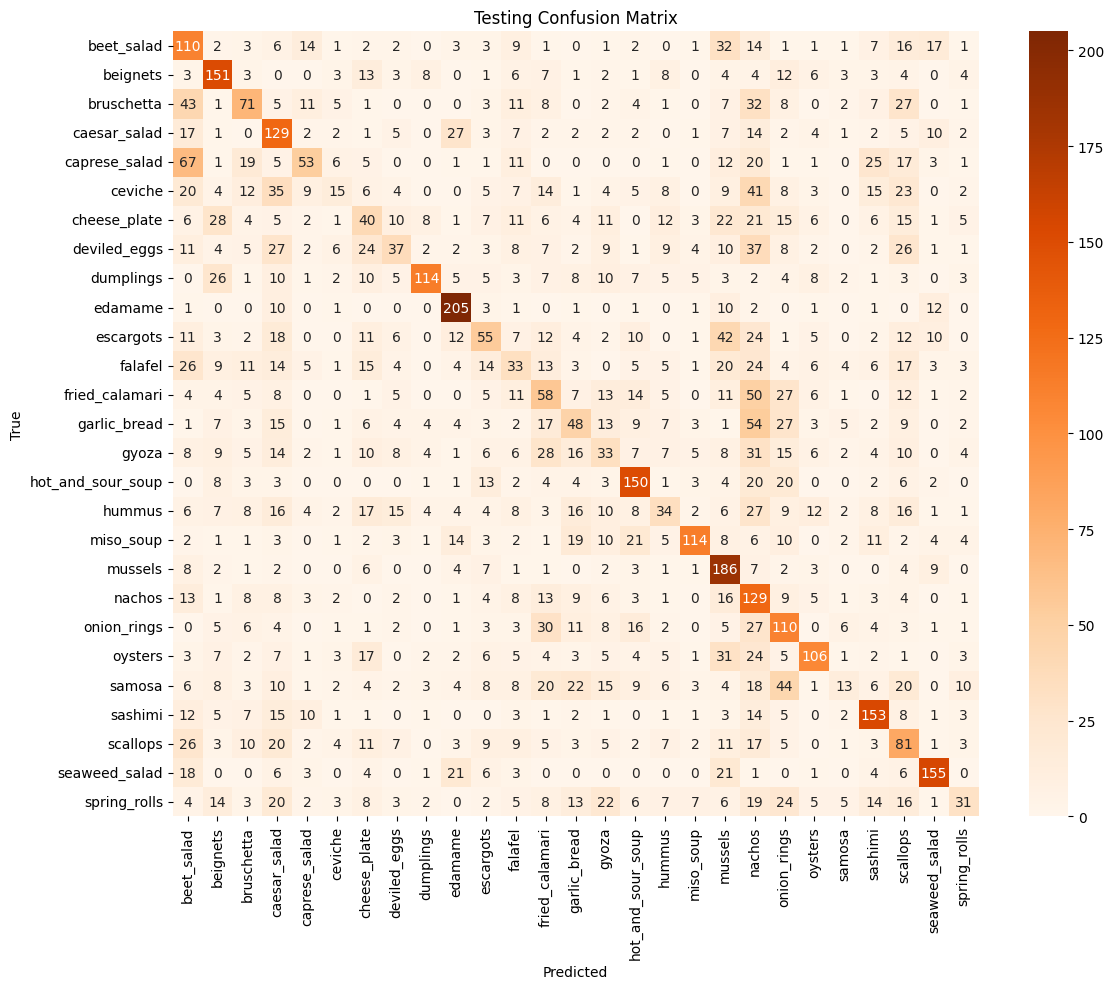

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot training confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(train_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=appetizer_classes, yticklabels=appetizer_classes)
plt.title("Training Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Plot testing confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=appetizer_classes, yticklabels=appetizer_classes)
plt.title("Testing Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


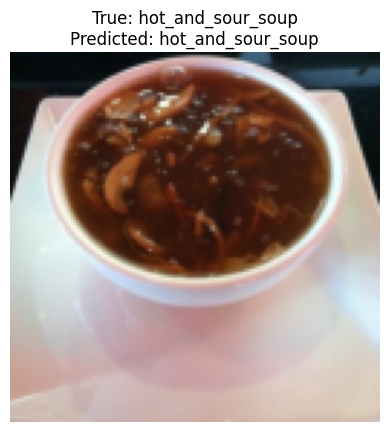

In [ ]:
import matplotlib.pyplot as plt
import torch

# Set your model to evaluation mode
model.eval()

# Get one sample from the test set (index can be changed)
image, true_label = test_data[0]

# Add batch dimension and move to device
image_tensor = image.unsqueeze(0).to(device)

# Run model prediction
with torch.no_grad():
    output = model(image_tensor)
    _, predicted_label = torch.max(output, 1)

# Un-normalize the image for display
unnormalized_img = image.permute(1, 2, 0) * 0.5 + 0.5  # Convert back to [0,1] range

# Show the image
plt.imshow(unnormalized_img.cpu())
plt.axis('off')
plt.title(f"True: {appetizer_classes[true_label]}\nPredicted: {appetizer_classes[predicted_label.item()]}")
plt.show()


In [16]:
# Save model weights to a file
model_path = "/content/appetizer_model.pth"
torch.save(model.state_dict(), model_path)
print(f"✅ Model saved at {model_path}")


✅ Model saved at /content/appetizer_model.pth


In [17]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [18]:
!cp /content/appetizer_model.pth /content/drive/MyDrive/
print("✅ Model copied to Google Drive at: MyDrive/appetizer_model.pth")


✅ Model copied to Google Drive at: MyDrive/appetizer_model.pth


## main course classifocation

In [20]:
# Main course classes
main_course_classes = [
    "baby_back_ribs",
    "beef_carpaccio",
    "beef_tartare",
    "bibimbap",
    "breakfast_burrito",
    "chicken_curry",
    "chicken_quesadilla",
    "chicken_wings",
    "club_sandwich",
    "croque_madame",
    "eggs_benedict",
    "filet_mignon",
    "fish_and_chips",
    "foie_gras",
    "french_onion_soup",
    "fried_rice",
    "grilled_cheese_sandwich",
    "grilled_salmon",
    "hamburger",
    "hot_and_sour_soup",
    "hot_dog",
    "huevos_rancheros",
    "lasagna",
    "lobster_bisque",
    "lobster_roll_sandwich",
    "macaroni_and_cheese",
    "omelette",
    "pad_thai",
    "paella",
    "pancakes",
    "peking_duck",
    "pho",
    "pizza",
    "pork_chop",
    "poutine",
    "prime_rib",
    "pulled_pork_sandwich",
    "ramen",
    "ravioli",
    "risotto",
    "shrimp_and_grits",
    "spaghetti_bolognese",
    "spaghetti_carbonara",
    "steak",
    "sushi",
    "tacos",
    "tuna_tartare"
]

main_course_indices = [train_set.class_to_idx[c] for c in main_course_classes]
class_to_new_label = {idx: new_idx for new_idx, idx in enumerate(main_course_indices)}

# Filter for main course images
def filter_main_courses(dataset):
    return [i for i, (_, label) in enumerate(dataset) if label in main_course_indices]

train_indices = filter_main_courses(train_set)
test_indices = filter_main_courses(test_set)

train_subset = Subset(train_set, train_indices)
test_subset = Subset(test_set, test_indices)


In [21]:
# Dataset relabel wrapper
class MainCourseDataset(torch.utils.data.Dataset):
    def __init__(self, subset, label_map):
        self.subset = subset
        self.label_map = label_map

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        return image, self.label_map[label]

train_data = MainCourseDataset(train_subset, class_to_new_label)
test_data = MainCourseDataset(test_subset, class_to_new_label)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32)


In [22]:
# CNN model
class MainCourseCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MainCourseCNN(num_classes=len(main_course_classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train for 1 epoch
model.train()
for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

In [24]:
# Evaluation
def evaluate(loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
    cm = confusion_matrix(all_labels, all_preds)
    TP = np.diag(cm)
    FN = np.sum(cm, axis=1) - TP
    sensitivity = TP / (TP + FN)
    accuracy = np.trace(cm) / np.sum(cm)
    return cm, sensitivity, accuracy

train_cm, train_sens, train_acc = evaluate(train_loader)
test_cm, test_sens, test_acc = evaluate(test_loader)

In [25]:
display(train_sens, train_acc)
display(test_sens, test_acc)

array([0.        , 0.004     , 0.016     , 0.43866667, 0.012     ,
       0.04      , 0.00666667, 0.        , 0.        , 0.33333333,
       0.00533333, 0.14266667, 0.        , 0.18      , 0.21333333,
       0.04666667, 0.004     , 0.        , 0.        , 0.00933333,
       0.        , 0.008     , 0.00266667, 0.34133333, 0.036     ,
       0.13866667, 0.00133333, 0.012     , 0.14666667, 0.00533333,
       0.076     , 0.392     , 0.00133333, 0.01466667, 0.05333333,
       0.14533333, 0.08      , 0.24      , 0.12133333, 0.216     ,
       0.02266667, 0.22      , 0.33866667, 0.13866667, 0.03866667,
       0.        , 0.08266667])

np.float64(0.09202836879432624)

array([0.008, 0.   , 0.004, 0.48 , 0.004, 0.036, 0.008, 0.   , 0.   ,
       0.268, 0.   , 0.108, 0.   , 0.18 , 0.188, 0.04 , 0.   , 0.   ,
       0.   , 0.004, 0.   , 0.   , 0.012, 0.396, 0.04 , 0.12 , 0.004,
       0.016, 0.124, 0.004, 0.076, 0.452, 0.004, 0.028, 0.068, 0.136,
       0.076, 0.204, 0.092, 0.276, 0.008, 0.248, 0.336, 0.108, 0.032,
       0.   , 0.044])

np.float64(0.09004255319148936)

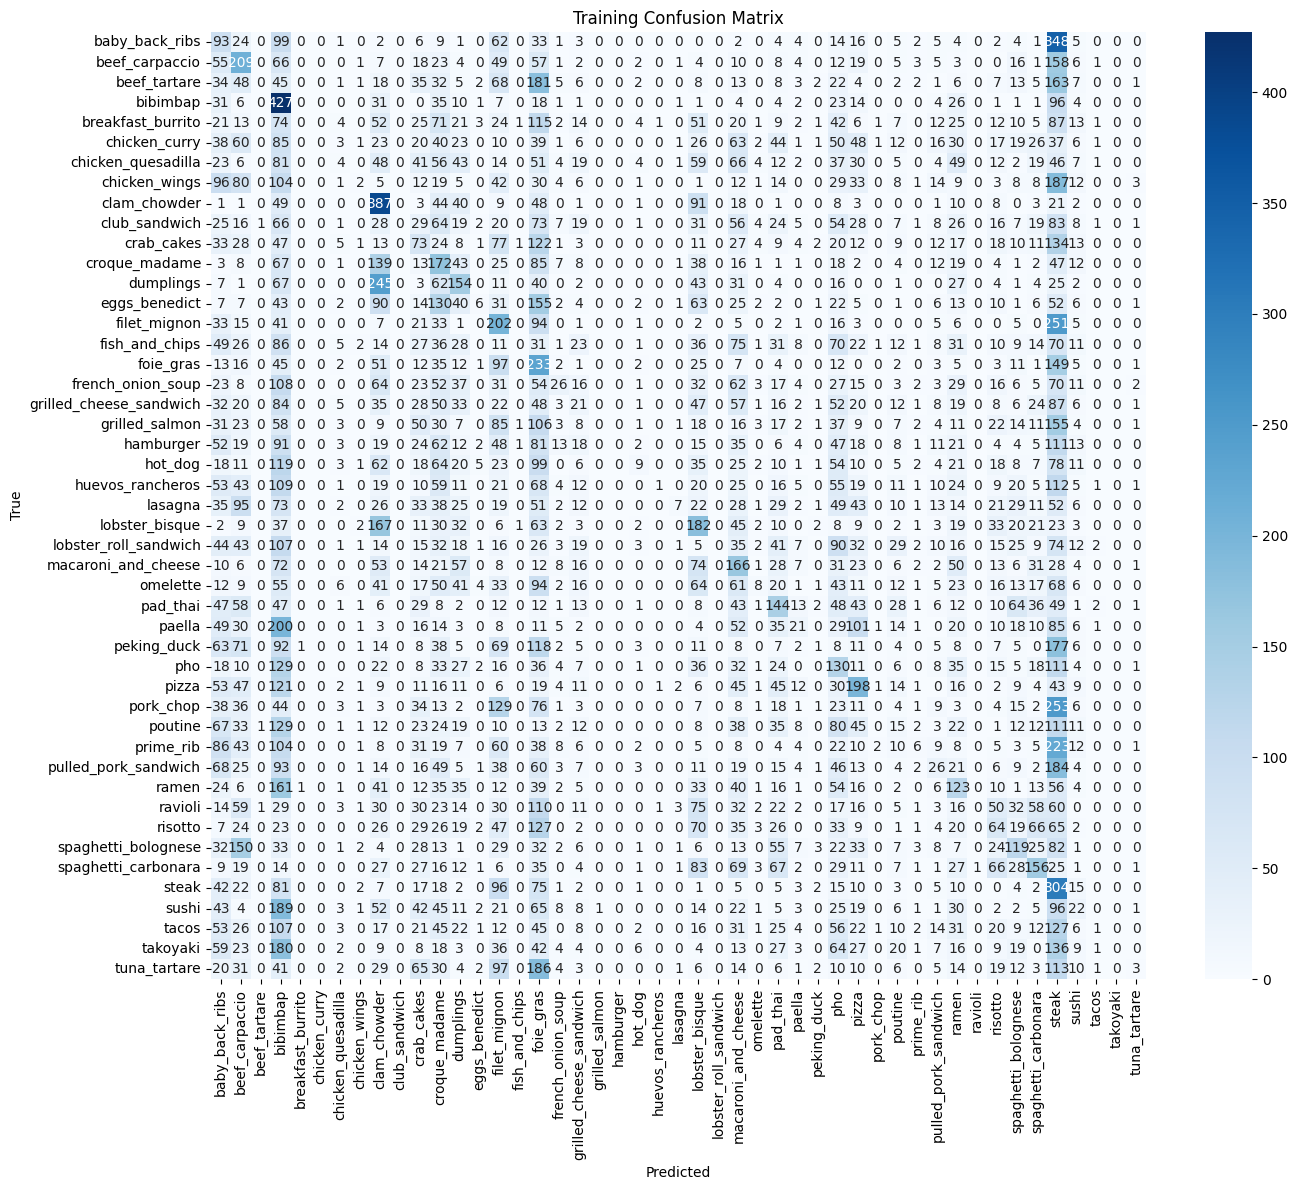

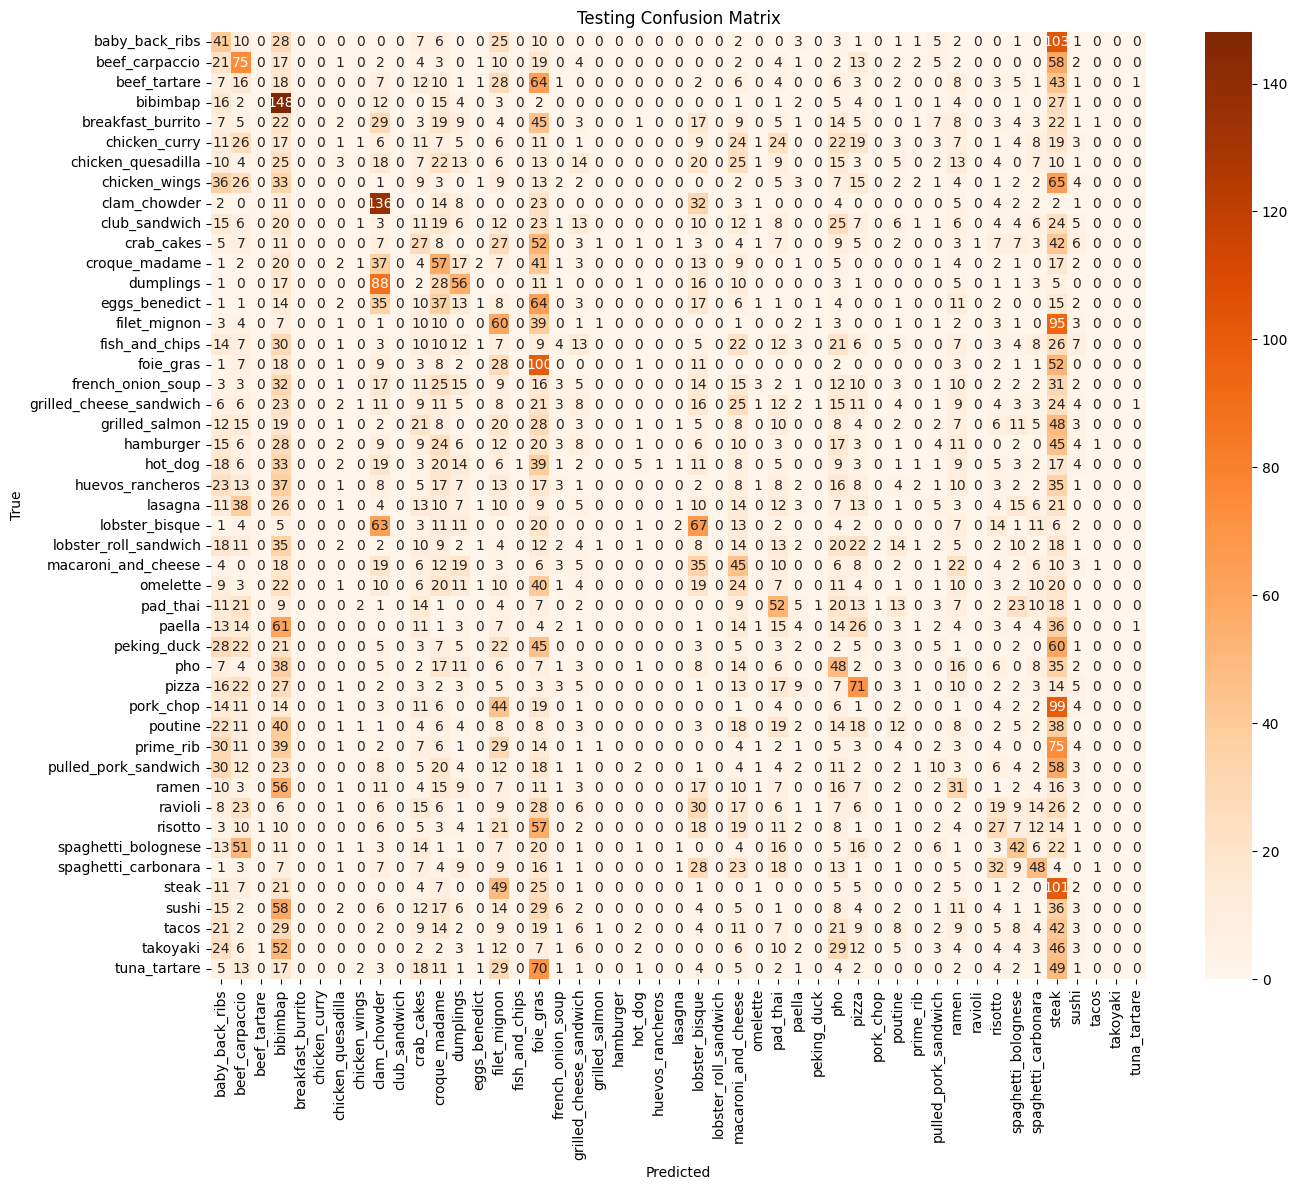

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Training Confusion Matrix
plt.figure(figsize=(14, 12))
sns.heatmap(train_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=main_course_classes, yticklabels=main_course_classes)
plt.title("Training Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Testing Confusion Matrix
plt.figure(figsize=(14, 12))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=main_course_classes, yticklabels=main_course_classes)
plt.title("Testing Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [26]:
# Save model weights
model_path = "/content/main_course_model.pth"
torch.save(model.state_dict(), model_path)
print("✅ Model saved at:", model_path)


✅ Model saved at: /content/main_course_model.pth


In [27]:
from google.colab import drive
drive.mount('/content/drive')

!cp /content/main_course_model.pth /content/drive/MyDrive/
print("✅ Model copied to Google Drive: MyDrive/main_course_model.pth")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model copied to Google Drive: MyDrive/main_course_model.pth


## desert model


In [28]:
dessert_classes = [
    "apple_pie", "baklava", "beignets", "bread_pudding", "carrot_cake", "cannoli",
    "cheesecake", "chocolate_cake", "chocolate_mousse", "churros", "creme_brulee",
    "cup_cakes", "donuts", "french_toast", "frozen_yogurt", "ice_cream", "macarons",
    "panna_cotta", "red_velvet_cake", "strawberry_shortcake", "tiramisu", "waffles"
]
# Map class indices and labels
dessert_indices = [train_set.class_to_idx[c] for c in dessert_classes]
class_to_new_label = {idx: new_idx for new_idx, idx in enumerate(dessert_indices)}

def filter_desserts(dataset):
    return [i for i, (_, label) in enumerate(dataset) if label in dessert_indices]


train_indices = filter_desserts(train_set)
test_indices = filter_desserts(test_set)

train_subset = Subset(train_set, train_indices)
test_subset = Subset(test_set, test_indices)

In [29]:
# Dataset wrapper
class DessertDataset(torch.utils.data.Dataset):
    def __init__(self, subset, label_map):
        self.subset = subset
        self.label_map = label_map

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        return image, self.label_map[label]



train_data = DessertDataset(train_subset, class_to_new_label)
test_data = DessertDataset(test_subset, class_to_new_label)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32)

In [30]:
# CNN model
class DessertCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DessertCNN(num_classes=len(dessert_classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train
model.train()
for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

In [32]:
# Evaluation
def evaluate(loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
    cm = confusion_matrix(all_labels, all_preds)
    TP = np.diag(cm)
    FN = np.sum(cm, axis=1) - TP
    sensitivity = TP / (TP + FN)
    accuracy = np.trace(cm) / np.sum(cm)
    return cm, sensitivity, accuracy

train_cm, train_sens, train_acc = evaluate(train_loader)
test_cm, test_sens, test_acc = evaluate(test_loader)

In [33]:
print("Training Sensitivity:", train_sens)
print(f"Training Accuracy: {train_acc:.2%}")
print("Validation Sensitivity:", test_sens)
print(f"Validation Accuracy: {test_acc:.2%}")

Training Sensitivity: [0.26666667 0.37866667 0.56266667 0.00533333 0.004      0.07333333
 0.05466667 0.588      0.01333333 0.11733333 0.176      0.224
 0.124      0.05866667 0.06       0.036      0.02533333 0.
 0.112      0.03466667 0.048      0.096     ]
Training Accuracy: 13.90%
Validation Sensitivity: [0.244 0.448 0.624 0.004 0.    0.044 0.06  0.588 0.024 0.096 0.244 0.232
 0.136 0.048 0.08  0.024 0.016 0.    0.108 0.016 0.04  0.096]
Validation Accuracy: 14.42%


In [34]:
model_path = "/content/dessert_model.pth"
torch.save(model.state_dict(), model_path)
print("✅ Model saved at:", model_path)

✅ Model saved at: /content/dessert_model.pth


In [35]:
!cp /content/dessert_model.pth /content/drive/MyDrive/
print("✅ Model copied to Google Drive: MyDrive/dessert_model.pth")

✅ Model copied to Google Drive: MyDrive/dessert_model.pth


## overall modell

In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [37]:
# Mapping of Food101 class names to binary labels
appetizer_classes = [
    "beet_salad",
    "bruschetta",
    "caesar_salad",
    "caprese_salad",
    "cheese_plate",
    "clam_chowder",
    "crab_cakes",
    "deviled_eggs",
    "dumplings",
    "edamame",
    "escargots",
    "falafel",
    "fried_calamari",
    "garlic_bread",
    "gnocchi",
    "greek_salad",
    "guacamole",
    "gyoza",
    "hummus",
    "miso_soup",
    "mussels",
    "nachos",
    "onion_rings",
    "oysters",
    "samosa",
    "spring_rolls",
    "takoyaki"
]

main_course_classes = [
    "baby_back_ribs",
    "beef_carpaccio",
    "beef_tartare",
    "bibimbap",
    "breakfast_burrito",
    "chicken_curry",
    "chicken_quesadilla",
    "chicken_wings",
    "club_sandwich",
    "croque_madame",
    "eggs_benedict",
    "filet_mignon",
    "fish_and_chips",
    "foie_gras",
    "french_onion_soup",
    "fried_rice",
    "grilled_cheese_sandwich",
    "grilled_salmon",
    "hamburger",
    "hot_and_sour_soup",
    "hot_dog",
    "huevos_rancheros",
    "lasagna",
    "lobster_bisque",
    "lobster_roll_sandwich",
    "macaroni_and_cheese",
    "omelette",
    "pad_thai",
    "paella",
    "pancakes",
    "peking_duck",
    "pho",
    "pizza",
    "pork_chop",
    "poutine",
    "prime_rib",
    "pulled_pork_sandwich",
    "ramen",
    "ravioli",
    "risotto",
    "shrimp_and_grits",
    "spaghetti_bolognese",
    "spaghetti_carbonara",
    "steak",
    "sushi",
    "tacos",
    "tuna_tartare"
]

dessert_classes = [
    "apple_pie",
    "baklava",
    "beignets",
    "bread_pudding",
    "carrot_cake",
    "cannoli",
    "cheesecake",
    "chocolate_cake",
    "chocolate_mousse",
    "churros",
    "creme_brulee",
    "cup_cakes",
    "donuts",
    "french_toast",
    "frozen_yogurt",
    "ice_cream",
    "macarons",
    "panna_cotta",
    "red_velvet_cake",
    "strawberry_shortcake",
    "tiramisu",
    "waffles"
]


# Class definitions
all_classes = appetizer_classes + main_course_classes + dessert_classes
class_to_idx_combined = {c: i for i, c in enumerate(all_classes)}
appetizer_to_idx = {c: i for i, c in enumerate(appetizer_classes)}
main_course_to_idx = {c: i for i, c in enumerate(main_course_classes)}
dessert_to_idx = {c: i for i, c in enumerate(dessert_classes)}

class_to_group = {c: 0 for c in appetizer_classes}
class_to_group.update({c: 1 for c in main_course_classes})
class_to_group.update({c: 2 for c in dessert_classes})


In [38]:
# Filter indices
relevant_classes = set(all_classes)
train_indices = [i for i, (_, label) in enumerate(train_set)
                 if train_set.classes[label] in relevant_classes]
test_indices = [i for i, (_, label) in enumerate(test_set)
                if test_set.classes[label] in relevant_classes]
train_subset = Subset(train_set, train_indices)
test_subset = Subset(test_set, test_indices)

In [39]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 16 * 16, 256)
        self.fc2 = nn.Linear(256, 3)  # Updated: 3 groups

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 128 * 16 * 16)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

class AppetizerCNN(nn.Module):
    def __init__(self, num_classes=len(appetizer_classes)):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256), nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

class MainCourseCNN(nn.Module):
    def __init__(self, num_classes=len(main_course_classes)):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

class DessertCNN(nn.Module):
    def __init__(self, num_classes=len(dessert_classes)):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x



In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load binary (3-group) model
binary_model = SimpleCNN().to(device)
binary_model.load_state_dict(torch.load("/content/drive/MyDrive/binary_model_new.pth"))
binary_model.eval()

# Load appetizer model
appetizer_model = AppetizerCNN().to(device)
appetizer_model.load_state_dict(torch.load("/content/drive/MyDrive/appetizer_model.pth"))
appetizer_model.eval()

# Load main course model
main_course_model = MainCourseCNN().to(device)
main_course_model.load_state_dict(torch.load("/content/drive/MyDrive/main_course_model.pth"))
main_course_model.eval()

# Load dessert model
dessert_model = DessertCNN().to(device)
dessert_model.load_state_dict(torch.load("/content/drive/MyDrive/dessert_model.pth"))
dessert_model.eval()



DessertCNN(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=22, bias=True)
  )
)

In [41]:
def predict_group_and_class(img_tensor):
    group = torch.argmax(binary_model(img_tensor), dim=1).item()
    if group == 0:
        pred = torch.argmax(appetizer_model(img_tensor), dim=1).item()
        return group, appetizer_classes[pred]
    elif group == 1:
        pred = torch.argmax(main_course_model(img_tensor), dim=1).item()
        return group, main_course_classes[pred]
    else:
        pred = torch.argmax(dessert_model(img_tensor), dim=1).item()
        return group, dessert_classes[pred]



In [49]:
def evaluate_dataset(subset, dataset_obj):
    true_combined, pred_combined = [], []
    with torch.no_grad():
        for img, label in subset:
            class_name = dataset_obj.classes[label]
            if class_name not in class_to_group:
                continue
            true_group = class_to_group[class_name]
            true_idx = class_to_idx_combined[class_name]
            input_tensor = img.unsqueeze(0).to(device)
            pred_group, pred_class_name = predict_group_and_class(input_tensor)

            if pred_group == true_group:
                pred_idx = class_to_idx_combined[pred_class_name]
                true_combined.append(true_idx)
                pred_combined.append(pred_idx)

    cm = confusion_matrix(true_combined, pred_combined, labels=list(range(len(all_classes))))
    acc = np.trace(cm) / np.sum(cm)
    sens = np.diag(cm) / (np.sum(cm, axis=1) + 1e-6)
    df = pd.DataFrame({
        "Class": all_classes,
        "Sensitivity": sens,
        "Index": range(len(all_classes)),
        "Confusion Matrix Row": cm.tolist()
    })
    return acc, df, true_combined, pred_combined




In [50]:
def plot_worst_confusion_matrix_with_nonzero(df, cm, all_classes, top_k=5, title="Confusion Matrix: Top Misclassified Classes"):
    # Filter out classes with 0 sensitivity
    df_nonzero = df[df["Sensitivity"] > 0]

    # Select top-k lowest-sensitivity classes
    df_sorted = df_nonzero.sort_values(by="Sensitivity").head(top_k)
    worst_classes = df_sorted["Class"].tolist()
    worst_indices = df_sorted["Index"].tolist()

    # Slice confusion matrix
    cm_worst = cm[np.ix_(worst_indices, worst_indices)]

    # Plot
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_worst, annot=True, fmt="d", cmap="Blues",
                xticklabels=worst_classes, yticklabels=worst_classes)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()
    plt.show()

    # Also print the class-sensitivity table
    print("🔍 Top Misclassified Classes (non-zero sensitivity):")
    print(df_sorted[["Class", "Sensitivity"]].to_string(index=False))


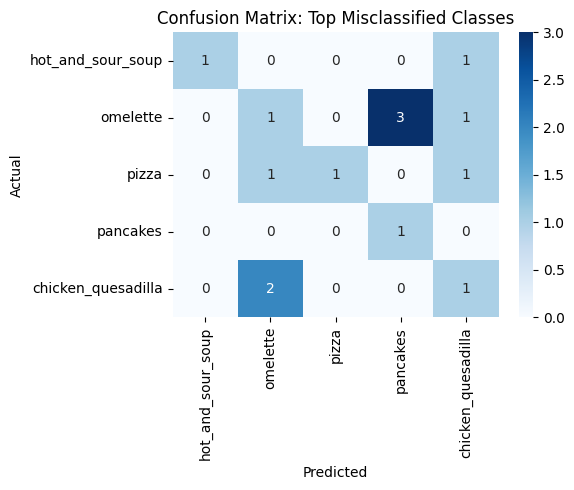

🔍 Top Misclassified Classes (non-zero sensitivity):
             Class  Sensitivity
 hot_and_sour_soup     0.004651
          omelette     0.004673
             pizza     0.004926
          pancakes     0.004950
chicken_quesadilla     0.004975


In [51]:
test_acc, test_df, test_true, test_pred = evaluate_dataset(test_subset, test_set)
cm_full = confusion_matrix(test_true, test_pred, labels=list(range(len(all_classes))))
plot_worst_confusion_matrix_with_nonzero(test_df, cm_full, all_classes, top_k=5)


In [44]:
# Core Python
import os
import numpy as np
import pandas as pd

# PyTorch & torchvision
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Subset, DataLoader, Dataset
from torchvision import transforms
from torchvision.datasets import Food101

# Metrics
from sklearn.metrics import confusion_matrix

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Google Colab (only needed if you're on Colab and using Google Drive)
from google.colab import drive


In [45]:
train_acc, train_df = evaluate_dataset(train_subset, train_set)
test_acc, test_df = evaluate_dataset(test_subset, test_set)

print(f"Train Accuracy: {train_acc:.2%}")
print(train_df.head())

print(f"Test Accuracy: {test_acc:.2%}")
print(test_df.head())



Train Accuracy: 15.52%
           Class  Sensitivity  \
0     beet_salad     0.435644   
1     bruschetta     0.114286   
2   caesar_salad     0.687161   
3  caprese_salad     0.310484   
4   cheese_plate     0.090909   

                                Confusion Matrix Row  
0  [132, 1, 16, 2, 1, 0, 2, 3, 1, 28, 2, 0, 0, 1,...  
1  [6, 12, 7, 2, 0, 1, 2, 4, 0, 1, 0, 0, 0, 0, 0,...  
2  [6, 0, 380, 1, 0, 2, 0, 4, 1, 29, 1, 1, 0, 3, ...  
3  [17, 4, 10, 77, 1, 0, 1, 5, 0, 6, 0, 1, 0, 0, ...  
4  [3, 0, 9, 1, 12, 9, 1, 8, 10, 4, 0, 0, 0, 2, 0...  
Test Accuracy: 14.31%
           Class  Sensitivity  \
0     beet_salad     0.245098   
1     bruschetta     0.100000   
2   caesar_salad     0.604167   
3  caprese_salad     0.172840   
4   cheese_plate     0.020833   

                                Confusion Matrix Row  
0  [25, 1, 5, 3, 1, 0, 0, 0, 0, 21, 0, 0, 0, 0, 0...  
1  [3, 3, 1, 3, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 1, ...  
2  [0, 0, 116, 0, 0, 0, 0, 2, 0, 13, 0, 0, 0, 1, ...  
3  [7, 

In [52]:
import pandas as pd

# Make sure cm_full and all_classes are already defined:
# cm_full = confusion_matrix(test_true, test_pred, labels=list(range(len(all_classes))))

# Create labeled DataFrame
cm_df = pd.DataFrame(cm_full, index=all_classes, columns=all_classes)

# Save to CSV
cm_df.to_csv("two_stage_cnn_final_confusion.csv")
print("✅ Confusion matrix saved as 'two_stage_cnn_final_confusion.csv'")


✅ Confusion matrix saved as 'two_stage_cnn_final_confusion.csv'
